# Logistic regression

**UWE Bristol · Introduction to Machine Learning**

This notebook walks through one classification model from start to finish: **Logistic regression**.

You will see:

1. how the model works, in plain language;
2. how to load, explore and prepare a dataset (pre-processing);
3. why we split the data into a training set and a test set;
4. how to train (fit) the model and make predictions;
5. how to measure performance with accuracy, a confusion matrix, precision, recall, F1 and a ROC curve;
6. how to visualise what the model has learned;
7. what happens when you change the model's settings.

No previous experience with the model is assumed. Run each cell in order with **Shift + Enter**, and
read the text above each cell before you run it.

## 1. How Logistic regression works

### The idea

Despite its name, logistic regression is used for **classification**. It works in two steps:

1. **Add up the evidence.** Each feature gets a **weight**. The model multiplies every feature by its
   weight and adds the results together, plus a constant called the **intercept**. A positive weight
   means "a bigger value of this feature points towards malignant"; a negative weight points towards benign.
2. **Turn the total into a probability.** The total can be any number, so it is passed through the
   **sigmoid** (or logistic) function, an S-shaped curve that squashes any number into the range 0 to 1.

If the probability of malignant is 0.5 or more, the model predicts malignant. Otherwise it predicts benign.

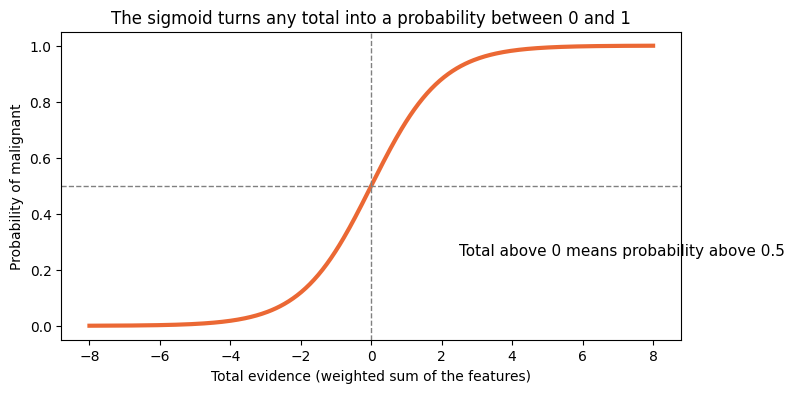

In [1]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-8, 8, 400)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid, color="#eb6834", lw=3)
plt.axhline(0.5, color="grey", ls="--", lw=1)
plt.axvline(0, color="grey", ls="--", lw=1)
plt.xlabel("Total evidence (weighted sum of the features)")
plt.ylabel("Probability of malignant")
plt.title("The sigmoid turns any total into a probability between 0 and 1")
plt.text(2.5, 0.25, "Total above 0 means probability above 0.5", fontsize=11)
plt.show()

### How are the weights chosen?

During training, the model adjusts the weights to make its probabilities match the real labels as
closely as possible. It is scored with **log loss**, which punishes confident wrong answers very
heavily. Predicting 0.99 for a tumour that is really benign costs far more than predicting 0.6.

### Regularisation and C

If the weights are allowed to become very large, the model can fit the training data too closely.
**Regularisation** adds a penalty for large weights. In scikit-learn the strength is set by **C**, and,
confusingly, it works backwards:

- **small C** means a **strong** penalty: small weights, a simpler model. Risk of underfitting.
- **large C** means a **weak** penalty: the model is free to fit the training data closely. Risk of overfitting.

### Why it is popular

Logistic regression is fast, reliable and, above all, **interpretable**. The weights tell you which
features push a prediction towards each class and by how much. That is why it is widely used in medicine
and finance, where decisions often need to be justified.

## Setting up

First we import the libraries we need. Each line has a comment saying what it is for.

In [2]:
# pandas holds data in tables (DataFrames); numpy does the number crunching
import pandas as pd
import numpy as np
# matplotlib draws our charts
import matplotlib.pyplot as plt

# The dataset, and tools for splitting and scaling it
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Performance measures and chart helpers
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay, roc_auc_score)
from sklearn.inspection import DecisionBoundaryDisplay

# The model for this notebook
from sklearn.linear_model import LogisticRegression

# Chart settings and colours used throughout
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
BENIGN_COLOUR = "#2a78d6"      # blue
MALIGNANT_COLOUR = "#eb6834"   # orange
TRAIN_COLOUR = "#1D1C21"       # dark grey
CHECK_COLOUR = "#2a78d6"       # blue

## 2. The dataset

We use the **Breast Cancer Wisconsin** dataset, which comes built into scikit-learn, so there is
nothing to download. Each row is one breast tumour. The columns are measurements taken from a
microscope image of cells from the tumour, such as the radius of the cell nuclei, their texture
(how varied the grey levels are) and how many concave points (inward dents) their outlines have.

Our job is to predict whether each tumour is **malignant** (cancerous) or **benign** (not cancerous).
There are only two possible answers, so this is a **binary classification** problem.

In [3]:
# Load the data as a pandas DataFrame
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

print("Number of tumours (rows):", df.shape[0])
print("Number of columns:", df.shape[1])
df.head()

Number of tumours (rows): 569
Number of columns: 31


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


There are 569 tumours and 31 columns: 30 measurements, which are the **features** (the inputs), and
a column called `target`, which is the **label** (the answer we want to predict).

The 30 features are really 10 measurements, each recorded in three ways: the `mean` across the cells
in the image, the `error` (how much the values varied) and the `worst` (the average of the three
largest values).

## 3. Exploring the data

Before building any model it is worth looking at the data. We want to know how many examples there
are of each class and whether the features look useful.

### Fixing the label

In this dataset `target` is **0 for malignant and 1 for benign**, which is the opposite of what most
people would expect. scikit-learn treats the class labelled 1 as the "positive" class when it calculates
precision and recall, and we care most about finding malignant tumours. So we make a new, clearer
label column where **1 means malignant** and **0 means benign**.

malignant
benign (0)       357
malignant (1)    212
Name: count, dtype: int64


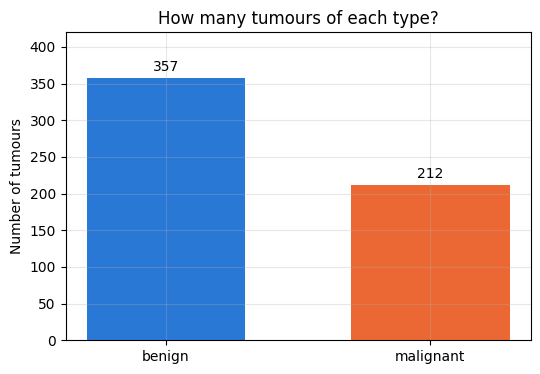

In [4]:
# New label: 1 = malignant, 0 = benign
df["malignant"] = (df["target"] == 0).astype(int)
df = df.drop(columns="target")

counts = df["malignant"].value_counts().sort_index()
print(counts.rename({0: "benign (0)", 1: "malignant (1)"}))

plt.figure(figsize=(6, 4))
bars = plt.bar(["benign", "malignant"], counts.values, color=[BENIGN_COLOUR, MALIGNANT_COLOUR], width=0.6)
plt.bar_label(bars, padding=3)
plt.ylabel("Number of tumours")
plt.title("How many tumours of each type?")
plt.ylim(0, 420)
plt.show()

There are 357 benign and 212 malignant tumours, so about 63% are benign. The classes are not
perfectly balanced. This gives us a useful **baseline**: a lazy "model" that always says benign would
be right about 63% of the time. Any real model has to do a lot better than that to be worth using.

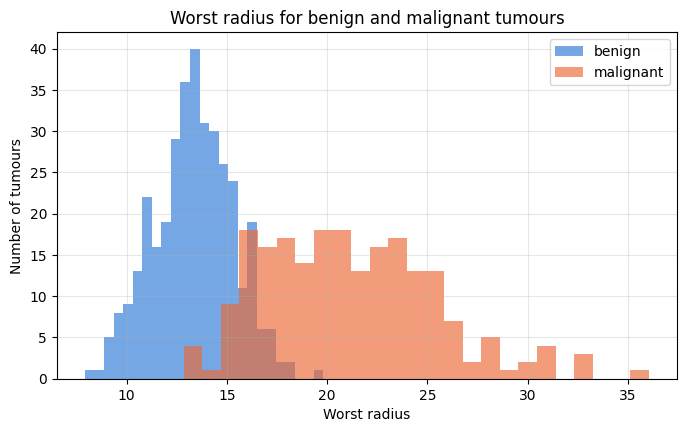

In [5]:
# Does one feature on its own separate the two classes?
plt.figure(figsize=(8, 4.5))
plt.hist(df.loc[df["malignant"] == 0, "worst radius"], bins=25, alpha=0.65,
         color=BENIGN_COLOUR, label="benign")
plt.hist(df.loc[df["malignant"] == 1, "worst radius"], bins=25, alpha=0.65,
         color=MALIGNANT_COLOUR, label="malignant")
plt.xlabel("Worst radius")
plt.ylabel("Number of tumours")
plt.title("Worst radius for benign and malignant tumours")
plt.legend()
plt.show()

Malignant tumours tend to have larger cells, but the two groups overlap in the middle. No single
measurement separates them perfectly, which is why we want a model that combines all 30.

## 4. Data pre-processing

Pre-processing means checking and preparing the data so that a model can learn from it properly.

### 4.1 Missing values and duplicates

In [6]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


This dataset has no missing values and no duplicated rows, which is unusual. With real-world data you
would normally need to deal with gaps, for example by removing incomplete rows or filling each gap
with the column's median value.

### 4.2 Separating the features (X) and the label (y)

By convention we call the inputs `X` and the answers `y`.

In [7]:
X = df.drop(columns="malignant")   # the 30 measurements
y = df["malignant"]                 # the answer: 1 = malignant, 0 = benign

print("X:", X.shape, "   y:", y.shape)

X: (569, 30)    y: (569,)


### 4.3 Do the features need scaling?

The features are measured on very different scales:

In [8]:
X[["mean radius", "mean area", "mean smoothness"]].describe().loc[["mean", "min", "max"]].round(3)

,mean radius,mean area,mean smoothness
mean,14.127,654.889,0.096
min,6.981,143.500,0.053
max,28.110,2501.000,0.163


`mean area` is in the hundreds, while `mean smoothness` is around 0.1. For this model that is a
problem. The model multiplies each feature by a weight, and the penalty on large weights treats all features the same. Without scaling, a feature measured in big numbers needs only a tiny weight and a feature in small numbers needs a huge one, so the penalty is unfair and the weights cannot be compared. Scaling also helps the training process finish quickly.

The fix is **standardisation** with `StandardScaler`. It rescales every feature so that its average is 0
and its standard deviation is 1, putting all 30 features on the same footing. We will do this in the
next section, **after** splitting the data, for a reason explained there.

## 5. The train/test split

If we trained a model on every tumour and then tested it on the same tumours, it could score well just
by remembering them. That would tell us nothing about how it will perform on **new** patients.

So we split the data into two parts:

- the **training set**, which the model learns from, and
- the **test set**, which we hide away and only use at the end to check how well the model works on
  tumours it has never seen.

The settings we use:

- `test_size=0.25`: keep 25% of the tumours for testing.
- `stratify=y`: keep the same proportion of malignant tumours in both parts.
- `random_state=42`: the split is random, but fixing this number means you get the same split every
  time you run the notebook (and the same as everyone else in the class).

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print("Training set:", len(X_train), "tumours")
print("Test set:    ", len(X_test), "tumours")
print("Malignant in training set:", round(y_train.mean() * 100, 1), "%")
print("Malignant in test set:    ", round(y_test.mean() * 100, 1), "%")

Training set: 426 tumours
Test set:     143 tumours
Malignant in training set: 37.3 %
Malignant in test set:     37.1 %


Thanks to `stratify=y`, both sets contain the same share of malignant tumours (about 37%).

### Scaling, after the split

Now we scale. There is one rule that matters a lot: the scaler must **learn only from the training
set**. It works out each feature's mean and standard deviation from the training data, and then uses
those same numbers to transform the test data.

If we scaled before splitting, the scaler would have seen the test tumours, and a little information
about the test set would leak into training. This is called **data leakage**, and it makes results
look slightly better than they really are.

In [10]:
scaler = StandardScaler()

# Learn the mean and standard deviation from the training set, then apply them
X_train_ready = scaler.fit_transform(X_train)

# Apply the SAME transformation to the test set (no fitting here)
X_test_ready = scaler.transform(X_test)

print("Mean area before scaling (training set):", round(X_train["mean area"].mean(), 1))
col = list(X.columns).index("mean area")
print("Mean area after scaling (training set): ", round(X_train_ready[:, col].mean(), 3))
print("Standard deviation after scaling:       ", round(X_train_ready[:, col].std(), 3))

Mean area before scaling (training set): 660.1
Mean area after scaling (training set):  0.0
Standard deviation after scaling:        1.0


## 6. Fitting (training) the model


We create the model and fit it. `max_iter` is the maximum number of steps the training process may take
to find the best weights. We raise it from the default so that training has time to finish.

In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_ready, y_train)

print("Number of weights learned:", model.coef_.shape[1])
print(f"Intercept: {model.intercept_[0]:.3f}")

Number of weights learned: 30
Intercept: -0.256


The model has learned one weight for each of the 30 features, plus the intercept. That is the whole model: 31 numbers.

## 7. Making predictions

With the model trained, we ask it to predict the label for every tumour in the **test set**. These are
tumours it has never seen.

As well as a yes/no answer, `predict_proba` gives the model's estimated **probability** that each
tumour is malignant. By default, the model predicts malignant when that probability is 0.5 or more.

In [12]:
y_pred = model.predict(X_test_ready)
y_prob = model.predict_proba(X_test_ready)[:, 1]   # probability of malignant

# Compare the first 10 predictions with the real answers
first_ten = pd.DataFrame({
    "actual": y_test.values[:10],
    "predicted": y_pred[:10],
    "probability of malignant": y_prob[:10].round(3),
})
first_ten["correct?"] = np.where(first_ten["actual"] == first_ten["predicted"], "yes", "NO")
first_ten

,actual,predicted,probability of malignant,correct?
0,1,1,0.999,yes
1,0,0,0.004,yes
2,1,1,1.000,yes
3,0,0,0.000,yes
4,0,0,0.035,yes
5,0,0,0.004,yes
6,0,0,0.000,yes
7,0,0,0.002,yes
8,0,0,0.007,yes
9,0,0,0.099,yes


## 8. Measuring performance

There are several ways to measure how good a classifier is. Each one answers a slightly different
question, and for a medical problem like this the differences really matter.

### 8.1 Accuracy

Accuracy is the simplest measure: **what fraction of predictions were correct?**

In [13]:
accuracy = accuracy_score(y_test, y_pred)
baseline = (y_test == 0).mean()   # always guessing "benign"

print(f"Accuracy of the model:          {accuracy:.3f}")
print(f"Accuracy of always saying benign: {baseline:.3f}")

Accuracy of the model:          0.965
Accuracy of always saying benign: 0.629


The model is well above the baseline. But accuracy on its own hides an important detail: **what kind
of mistakes** did the model make?

### 8.2 The confusion matrix

A confusion matrix sorts every prediction into one of four boxes:

| | Model says benign | Model says malignant |
|---|---|---|
| **Really benign** | True negative (TN): correct | False positive (FP): a false alarm |
| **Really malignant** | False negative (FN): a missed cancer | True positive (TP): correct |

The two kinds of mistake are not equally bad. A false alarm means a worried patient and an extra test.
A false negative means a cancer is missed.

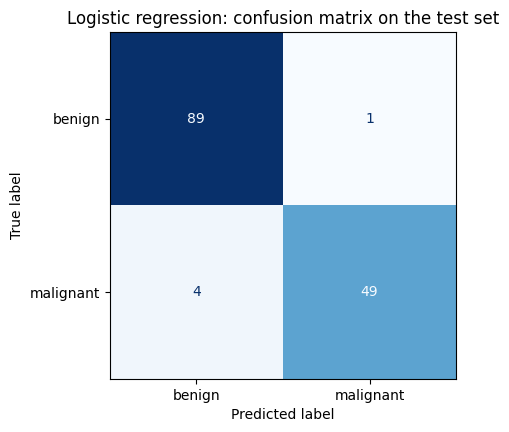

True negatives  (benign, correctly identified):    89
False positives (benign, wrongly called malignant): 1
False negatives (malignant, missed):               4
True positives  (malignant, correctly found):      49


In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["benign", "malignant"], cmap="Blues", colorbar=False
)
plt.title("Logistic regression: confusion matrix on the test set")
plt.grid(False)
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"True negatives  (benign, correctly identified):    {tn}")
print(f"False positives (benign, wrongly called malignant): {fp}")
print(f"False negatives (malignant, missed):               {fn}")
print(f"True positives  (malignant, correctly found):      {tp}")

### 8.3 Precision, recall and F1

These three measures focus on the malignant class:

- **Precision** = TP / (TP + FP). Of all the tumours the model *called* malignant, what fraction really
  were? High precision means few false alarms.
- **Recall** = TP / (TP + FN). Of all the tumours that *really were* malignant, what fraction did the
  model find? High recall means few missed cancers. (Recall is also called **sensitivity**.)
- **F1 score** combines precision and recall into one number. It is only high when both are high.

For cancer screening, recall is usually the most important of these, because missing a cancer is the
worst outcome.

In [15]:
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1 score:  {f1_score(y_test, y_pred):.3f}")

Precision: 0.980
Recall:    0.925
F1 score:  0.951


`classification_report` prints all of these at once, for **both** classes. The `support` column is the
number of test tumours in each class.

In [16]:
print(classification_report(y_test, y_pred, target_names=["benign", "malignant"]))

              precision    recall  f1-score   support

      benign       0.96      0.99      0.97        90
   malignant       0.98      0.92      0.95        53

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



### 8.4 The ROC curve and AUC

The model's decision depends on the 0.5 probability threshold. If we lowered the threshold, it would
catch more malignant tumours but raise more false alarms; if we raised it, the opposite.

A **ROC curve** shows this trade-off across every possible threshold. It plots the **true positive
rate** (recall) against the **false positive rate** (the fraction of benign tumours wrongly flagged).
A perfect model goes straight up the left side and along the top. A model that guesses at random
follows the dashed diagonal line.

The **AUC** (area under the curve) sums this up in one number, from 0.5 (guessing) to 1.0 (perfect).

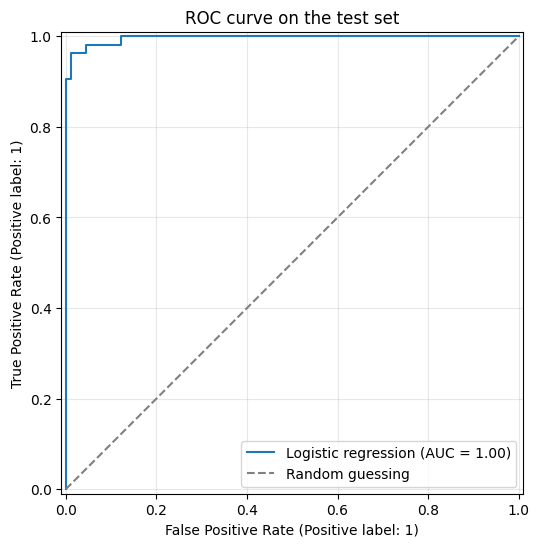

AUC: 0.996


In [17]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, y_prob, name="Logistic regression", ax=ax)
ax.plot([0, 1], [0, 1], "--", color="grey", label="Random guessing")
ax.set_title("ROC curve on the test set")
ax.legend(loc="lower right")
plt.show()

print(f"AUC: {roc_auc_score(y_test, y_prob):.3f}")

## 9. Looking inside the model

### The S-curve on real data

To see the sigmoid at work, we fit a logistic regression using just **one** feature, `worst radius`.
Each dot is a training tumour, placed at 0 (benign) or 1 (malignant), with a little vertical jitter so the
dots do not sit on top of each other. The orange curve is the model's probability of malignant.

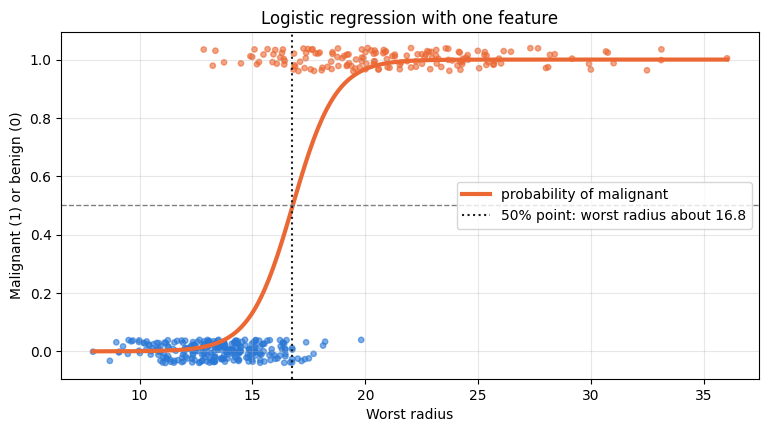

In [18]:
one_feature = LogisticRegression(max_iter=1000).fit(X_train[["worst radius"]], y_train)

radius = np.linspace(X_train["worst radius"].min(), X_train["worst radius"].max(), 300)
prob = one_feature.predict_proba(pd.DataFrame({"worst radius": radius}))[:, 1]
jitter = np.random.default_rng(0).uniform(-0.04, 0.04, len(y_train))
colours = np.where(y_train == 1, MALIGNANT_COLOUR, BENIGN_COLOUR)

plt.figure(figsize=(9, 4.5))
plt.scatter(X_train["worst radius"], y_train + jitter, c=colours, s=15, alpha=0.6)
plt.plot(radius, prob, color=MALIGNANT_COLOUR, lw=3, label="probability of malignant")
plt.axhline(0.5, color="grey", ls="--", lw=1)
cut = radius[np.argmin(np.abs(prob - 0.5))]
plt.axvline(cut, color="#1D1C21", ls=":", lw=1.5, label=f"50% point: worst radius about {cut:.1f}")
plt.xlabel("Worst radius")
plt.ylabel("Malignant (1) or benign (0)")
plt.title("Logistic regression with one feature")
plt.legend(loc="center right")
plt.show()

Small tumours get a probability near 0, large ones near 1, and the curve rises most steeply where the
two groups overlap.

### What do the weights tell us?

With scaled features, we can compare the weights directly. Here are the 10 largest, positive and negative.

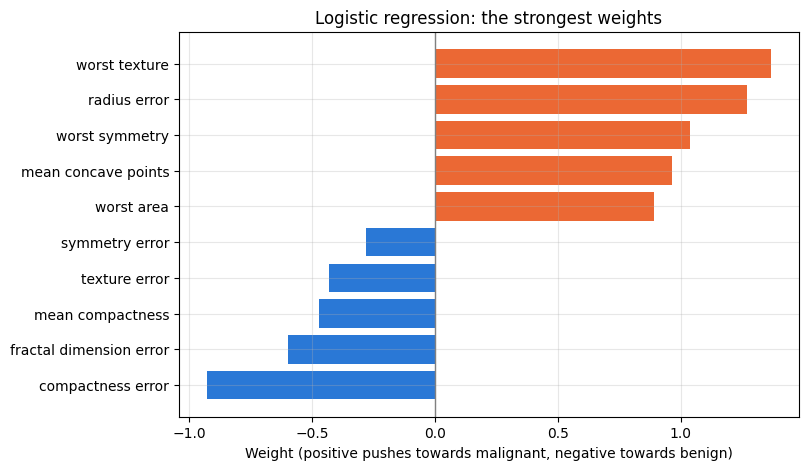

In [19]:
weights = pd.Series(model.coef_[0], index=X.columns).sort_values()
top = pd.concat([weights.head(5), weights.tail(5)])

plt.figure(figsize=(8, 5))
plt.barh(top.index, top.values, color=[BENIGN_COLOUR if w < 0 else MALIGNANT_COLOUR for w in top])
plt.axvline(0, color="grey", lw=1)
plt.xlabel("Weight (positive pushes towards malignant, negative towards benign)")
plt.title("Logistic regression: the strongest weights")
plt.show()

A word of caution: many of these features are closely related (radius, perimeter and area all measure
size), so the model can share weight between them in odd ways. A feature with a small or negative weight
is not necessarily unimportant on its own.

### Moving the threshold

The model predicts malignant when the probability is at least 0.5, but we can choose a different
threshold. A lower threshold catches more cancers but raises more false alarms.

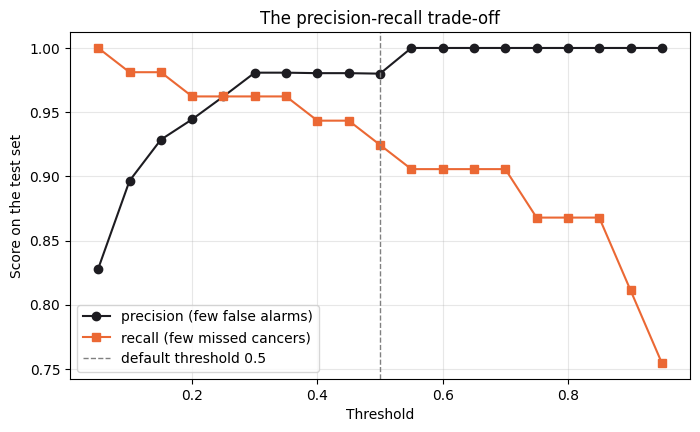

threshold 0.2: missed cancers = 2, false alarms = 3
threshold 0.5: missed cancers = 4, false alarms = 1
threshold 0.8: missed cancers = 7, false alarms = 0


In [20]:
thresholds = np.linspace(0.05, 0.95, 19)
precisions = [precision_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
recalls = [recall_score(y_test, (y_prob >= t).astype(int)) for t in thresholds]

plt.figure(figsize=(8, 4.5))
plt.plot(thresholds, precisions, "o-", color=TRAIN_COLOUR, label="precision (few false alarms)")
plt.plot(thresholds, recalls, "s-", color=MALIGNANT_COLOUR, label="recall (few missed cancers)")
plt.axvline(0.5, color="grey", ls="--", lw=1, label="default threshold 0.5")
plt.xlabel("Threshold")
plt.ylabel("Score on the test set")
plt.title("The precision-recall trade-off")
plt.legend(loc="lower left")
plt.show()

for t in [0.2, 0.5, 0.8]:
    p = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, p).ravel()
    print(f"threshold {t}: missed cancers = {fn}, false alarms = {fp}")

Choosing the threshold is a decision about which mistake matters more, not a purely technical one. In
screening, a lower threshold is often preferred. (Strictly, the threshold should be chosen using the
training data or a validation set; we use the test set here only to show the effect.)

## 10. Seeing the decision boundary

With 30 features we cannot draw what the model has learned. But if we train the same kind of model on
just **two** features, we can plot every tumour on a flat chart and colour in the regions where the
model would predict benign or malignant. The line where the colours meet is the **decision boundary**.

We use `mean radius` and `mean texture`. These two features overlap quite a lot, which makes the
boundary more interesting to look at. This two-feature model is only for the picture; our real model
still uses all 30 features.

Because this model needs scaled data, we use `make_pipeline`, which bundles a scaler and the model
together so that scaling happens automatically, learned from the training data only.

Logistic regression always draws a **straight** boundary (with two features, a straight line). On the
left the penalty is strong (small C); on the right it is weak (large C).

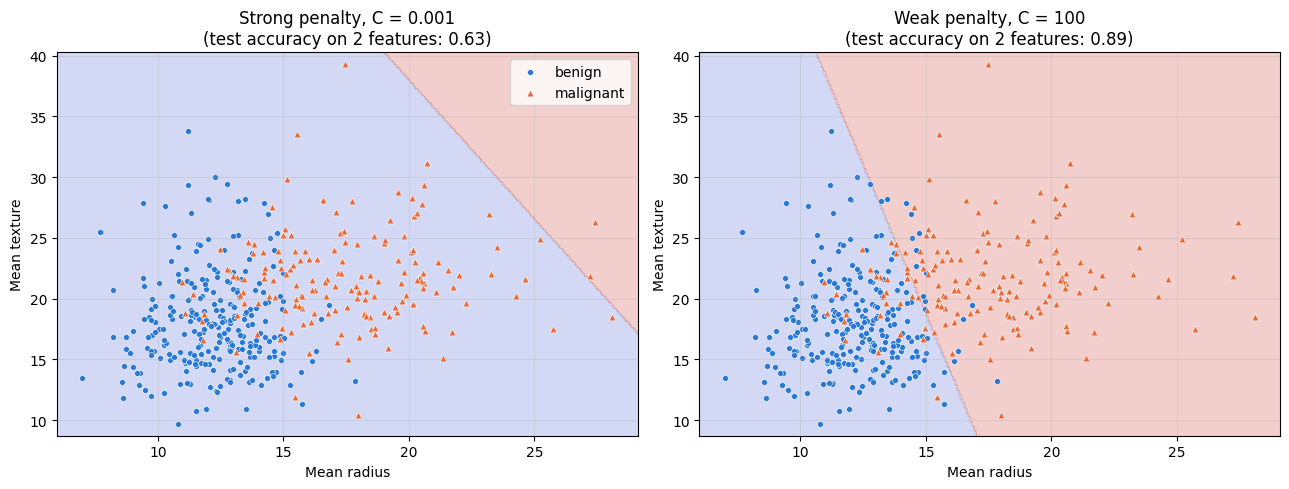

In [21]:
two = ["mean radius", "mean texture"]
X_two = X_train[two]

def draw_boundary(model, ax, title):
    """Fit a model on two features and colour in its predictions."""
    model.fit(X_two, y_train)
    DecisionBoundaryDisplay.from_estimator(
        model, X_two, response_method="predict", ax=ax, alpha=0.25,
        cmap="coolwarm", grid_resolution=300, xlabel="Mean radius", ylabel="Mean texture"
    )
    benign = y_train == 0
    ax.scatter(X_two.loc[benign, two[0]], X_two.loc[benign, two[1]], s=18,
               color=BENIGN_COLOUR, edgecolor="white", linewidth=0.4, label="benign")
    ax.scatter(X_two.loc[~benign, two[0]], X_two.loc[~benign, two[1]], s=24, marker="^",
               color=MALIGNANT_COLOUR, edgecolor="white", linewidth=0.4, label="malignant")
    acc = model.score(X_test[two], y_test)
    ax.set_title(f"{title}\n(test accuracy on 2 features: {acc:.2f})")


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
draw_boundary(make_pipeline(StandardScaler(), LogisticRegression(C=0.001, max_iter=1000)), axes[0],
              "Strong penalty, C = 0.001")
draw_boundary(make_pipeline(StandardScaler(), LogisticRegression(C=100, max_iter=1000)), axes[1],
              "Weak penalty, C = 100")
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()

## 11. Changing the parameters

Every model has settings that we choose before training. These are called **hyperparameters**.
Changing them changes how simple or complex the model is.

### Choosing settings fairly

We must **not** use the test set to choose settings. If we tried lots of settings and kept whichever
did best on the test set, the test set would no longer be a fair check.

Instead we use **cross-validation** on the training set. The training data is split into 5 parts. The
model trains on 4 parts and is checked on the 5th, and this is repeated so that each part gets a turn.
The average of the 5 scores tells us how well a setting works on data the model did not train on.

The function below tries a list of values for one setting and plots two lines:

- **training accuracy**: how well the model does on the data it learned from;
- **cross-validated accuracy**: our fair estimate of how it will do on new data.

A big gap between the two lines is a sign of **overfitting**: the model has memorised the training data.
When both lines are low, the model is **underfitting**: it is too simple to capture the pattern.

### C: the strength of regularisation

We try C from very small (strong penalty, simple model) to very large (weak penalty). We use
`make_pipeline` so that, inside cross-validation, the scaler is re-learned on each training fold, which
is why we pass the unscaled `X_train`.

In [22]:
def try_settings(make_model, values, setting_name, X_data, log_scale=False, tolerance=0):
    """Try each value of one setting; plot training vs cross-validated accuracy.

    The values must be listed from simplest to most complex. The chosen value is the simplest
    one whose cross-validated accuracy is within `tolerance` of the best.
    """
    train_scores, cv_scores = [], []
    for value in values:
        m = make_model(value)
        cv_scores.append(cross_val_score(m, X_data, y_train, cv=5).mean())
        train_scores.append(m.fit(X_data, y_train).score(X_data, y_train))

    plt.plot(values, train_scores, "o-", color=TRAIN_COLOUR, label="Training accuracy")
    plt.plot(values, cv_scores, "s-", color=CHECK_COLOUR, label="Cross-validated accuracy")
    if log_scale:
        plt.xscale("log")
    plt.xlabel(setting_name)
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    table = pd.DataFrame({setting_name: values,
                          "training accuracy": np.round(train_scores, 3),
                          "cross-validated accuracy": np.round(cv_scores, 3)})
    top = max(cv_scores)
    best = next(v for v, s in zip(values, cv_scores) if s >= top - tolerance - 1e-9)
    return table, best

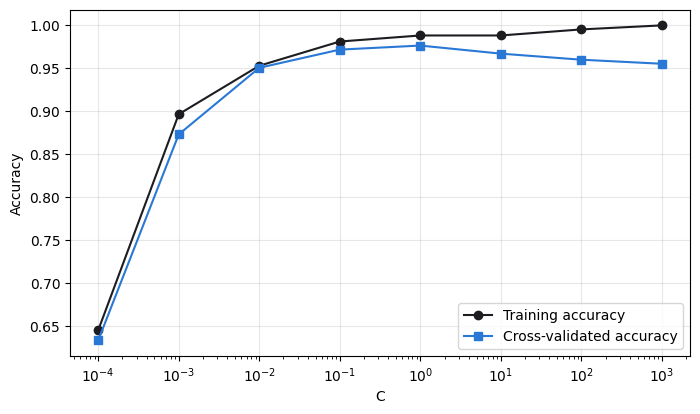

Chosen C: 1


,C,training accuracy,cross-validated accuracy
0,0.0001,0.646,0.634
1,0.0010,0.897,0.873
2,0.0100,0.953,0.951
3,0.1000,0.981,0.972
4,1.0000,0.988,0.977
5,10.0000,0.988,0.967
6,100.0000,0.995,0.960
7,1000.0000,1.000,0.955


In [23]:
c_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
table, best_c = try_settings(lambda c: make_pipeline(StandardScaler(), LogisticRegression(C=c, max_iter=5000)),
                             c_values, "C", X_train, log_scale=True)
print("Chosen C:", best_c)
table

**What to notice:** with a very strong penalty, the weights are squeezed towards zero and the model
underfits. As C increases, training accuracy keeps rising, but the cross-validated accuracy peaks and
then falls slightly as the model starts to fit noise.

### How C changes the weights

In [24]:
for c in [0.01, 1, 100]:
    m = LogisticRegression(C=c, max_iter=5000).fit(X_train_ready, y_train)
    print(f"C = {c:>6}: largest weight = {np.abs(m.coef_).max():6.2f}, "
          f"average size of weights = {np.abs(m.coef_).mean():5.2f}")

C =   0.01: largest weight =   0.24, average size of weights =  0.13
C =      1: largest weight =   1.37, average size of weights =  0.59
C =    100: largest weight =   9.43, average size of weights =  3.60


A larger C lets the weights grow much bigger, which is what allows the model to fit the training data more closely.

### Retraining with the chosen setting

Now we train a fresh model with the chosen setting on the whole training set, and check it **once** on
the test set. We compare it with the default model from earlier.

In [25]:
tuned = LogisticRegression(C=best_c, max_iter=5000)
tuned.fit(X_train_ready, y_train)
tuned_pred = tuned.predict(X_test_ready)

summary = pd.DataFrame({
    "default model": [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
                      recall_score(y_test, y_pred), f1_score(y_test, y_pred)],
    "tuned model":   [accuracy_score(y_test, tuned_pred), precision_score(y_test, tuned_pred),
                      recall_score(y_test, tuned_pred), f1_score(y_test, tuned_pred)],
}, index=["accuracy", "precision", "recall", "F1"]).round(3)
summary

,default model,tuned model
accuracy,0.965,0.965
precision,0.980,0.980
recall,0.925,0.925
F1,0.951,0.951


Tuning does not always change the result. Sometimes the default settings are already a good choice, or
the chosen setting happens to make the same predictions on these 143 test tumours. Occasionally a tuned
model even does slightly worse on the test set, because cross-validation gives a fair **estimate**, not a
guarantee. What matters is that the setting was chosen without looking at the test set, so the test
score is an honest measure of how the model is likely to perform on new patients.

## 12. Discussion

### Strengths

- Fast to train and to use, even on large datasets.
- Gives well-behaved probabilities, not just yes/no answers.
- **Interpretable**: the weights show how each feature pushes the prediction.
- Hard to beat as a baseline, and often surprisingly competitive.


### Limitations

- Draws only straight-line (linear) boundaries unless you create extra features yourself.
- Needs scaled features for the weights and penalty to behave sensibly.
- Weights can be misleading when features are strongly related to each other.
- Can be beaten by more flexible models when the true pattern is complex.


### Where it is used

- Medical risk scores, such as estimating the chance of a disease from test results.
- Credit scoring: the probability that a loan will not be repaid.
- Marketing: the probability that a customer clicks an advert or buys a product.
- Any setting where decisions must be explained to people or regulators.


### When should you choose it?

Logistic regression is an excellent first model for almost any binary classification problem, and the
natural choice when you need probabilities you can trust and a model you can explain.


## 13. Summary of the process

Every supervised learning project in this module follows the same steps you have just worked through:

1. **Understand the problem and the data**: what are the features, what is the label?
2. **Explore** the data: class balance, useful features, anything odd.
3. **Pre-process**: deal with missing values, fix labels, and scale if the model needs it.
4. **Split** into training and test sets, with scaling learned from the training set only.
5. **Fit** the model to the training data.
6. **Predict** on the test set.
7. **Measure** performance with more than one metric, thinking about which mistakes matter most.
8. **Tune** the settings with cross-validation, then check the final model once on the test set.

## 14. Your turn


1. Change `C` in section 6 to 0.001 and look at the confusion matrix. What has happened?
2. Using the threshold chart, find a threshold that misses no more than one cancer. How many false alarms does it produce?
3. Refit the one-feature model in section 9 using `worst concave points` instead of `worst radius`. Is the S-curve steeper or shallower? What does that tell you?
4. Train the model without scaling (use `X_train` and `X_test` in section 6). You may see a `ConvergenceWarning`. What do you think it means, and how do the weights compare with the scaled version?
5. Explain in your own words why logistic regression is a **classification** model, despite having "regression" in its name.